# Milestone 1: Data Collection, EDA, and Hypothesis Testing

This notebook analyzes the Online Retail II dataset to explore customer behavior and test whether high-value customers differ from low-value customers in terms of purchase frequency.

The main goal is to investigate whether frequency can be used as an early signal for identifying valuable customers.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

In [4]:
df = pd.read_excel("online_retail_II.xlsx", sheet_name="Year 2010-2011")
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
# Data cleaning
df = df.dropna()
df = df[df["Quantity"] > 0]
df = df[df["Price"] > 0]

# Create total spending per row
df["TotalPrice"] = df["Quantity"] * df["Price"]

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


## Data Cleaning

The dataset was cleaned by:
- removing missing values
- removing transactions with non-positive quantity
- removing transactions with non-positive price

A new variable called `TotalPrice` was created by multiplying quantity and price.

In [6]:
# Create customer-level features
customer_df = df.groupby("Customer ID").agg({
    "Invoice": "nunique",
    "TotalPrice": "sum"
}).reset_index()

# Rename columns
customer_df.columns = ["CustomerID", "Frequency", "Monetary"]

customer_df.head()

,CustomerID,Frequency,Monetary
0,12346.0,1,77183.60
1,12347.0,7,4310.00
2,12348.0,4,1797.24
3,12349.0,1,1757.55
4,12350.0,1,334.40


## Customer-Level Aggregation

The data was aggregated at the customer level:

- **Frequency**: number of unique invoices per customer
- **Monetary**: total spending of each customer

This allows us to analyze customer behavior instead of individual transactions.

In [7]:
# Define high-value customers as the top 20% by monetary value
threshold = customer_df["Monetary"].quantile(0.80)
customer_df["HighValue"] = (customer_df["Monetary"] >= threshold).astype(int)

customer_df["HighValue"].value_counts()

HighValue
0    3470
1     868
Name: count, dtype: int64

## High-Value Customer Definition

High-value customers are defined as the top 20% of customers in terms of total monetary value.

Customers in this group are labeled as `HighValue = 1`, while the rest are labeled as `HighValue = 0`.

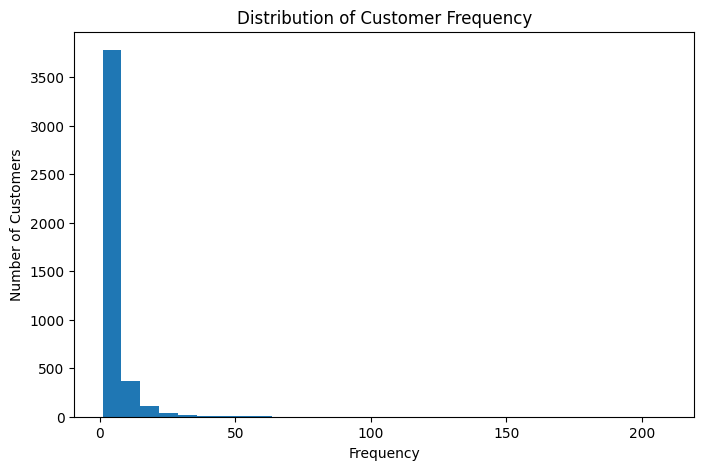

In [8]:
plt.figure(figsize=(8,5))
plt.hist(customer_df["Frequency"], bins=30)
plt.title("Distribution of Customer Frequency")
plt.xlabel("Frequency")
plt.ylabel("Number of Customers")
plt.show()

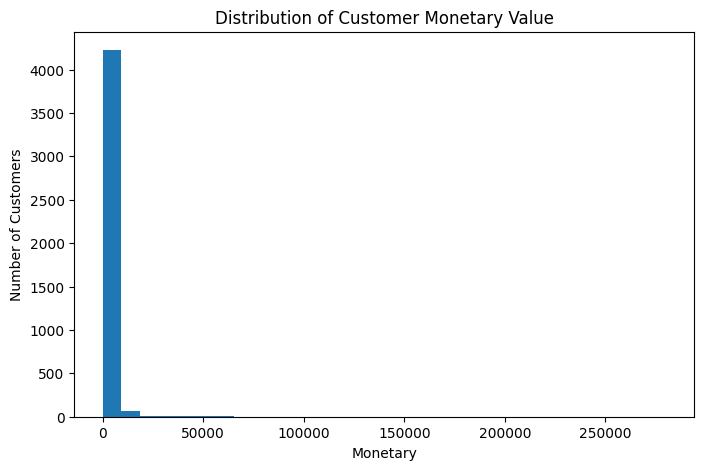

In [9]:
plt.figure(figsize=(8,5))
plt.hist(customer_df["Monetary"], bins=30)
plt.title("Distribution of Customer Monetary Value")
plt.xlabel("Monetary")
plt.ylabel("Number of Customers")
plt.show()

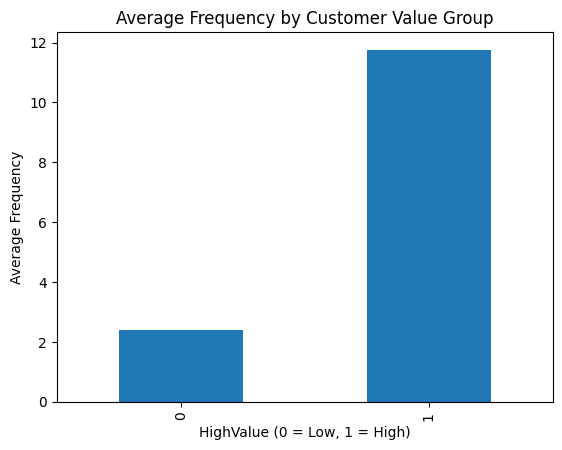

In [10]:
customer_df.groupby("HighValue")["Frequency"].mean().plot(kind="bar")
plt.title("Average Frequency by Customer Value Group")
plt.xlabel("HighValue (0 = Low, 1 = High)")
plt.ylabel("Average Frequency")
plt.show()

## EDA Insight

The distribution of customer purchase frequency is highly right-skewed. Most customers make only a small number of purchases, while a small subset of customers purchase much more frequently.

This pattern is typical in e-commerce and suggests that a limited number of customers contribute disproportionately to overall customer value.

In [11]:
high_freq = customer_df[customer_df["HighValue"] == 1]["Frequency"]
low_freq = customer_df[customer_df["HighValue"] == 0]["Frequency"]

stat, p_value = mannwhitneyu(high_freq, low_freq)

print("Mann-Whitney U statistic:", stat)
print("p-value:", p_value)

Mann-Whitney U statistic: 2797287.5
p-value: 0.0


## Hypothesis Test

**Null hypothesis (H0):** There is no significant difference in purchase frequency between high-value and low-value customers.

**Alternative hypothesis (H1):** There is a significant difference in purchase frequency between high-value and low-value customers.

Since purchase behavior data is highly skewed and not normally distributed, the Mann-Whitney U test was used.

In [12]:
if p_value < 0.05:
    print("Reject H0: There is a statistically significant difference in frequency between high-value and low-value customers.")
else:
    print("Fail to reject H0: There is no statistically significant difference in frequency between the two groups.")

Reject H0: There is a statistically significant difference in frequency between high-value and low-value customers.


## Conclusion

The hypothesis test produced a p-value of 0.0, which is far below the 0.05 significance threshold. Therefore, the null hypothesis is rejected.

This result indicates that high-value customers differ significantly from low-value customers in terms of purchase frequency. This suggests that purchase frequency may be a strong behavioral signal for identifying valuable customers early.

## Results Summary

- The dataset was cleaned and transformed into customer-level features.
- High-value customers were defined as the top 20% in terms of total spending.
- Exploratory data analysis showed that customer behavior is highly skewed.
- A Mann-Whitney U test confirmed a statistically significant difference in purchase frequency between high-value and low-value customers.

Overall, the analysis suggests that purchase frequency is a strong indicator of customer value.